In [ ]:
!hostname

cn837.wexac.weizmann.ac.il


In [2]:
import os
import sys
import numpy as np
import pandas as pd



REMOVE_OUTLIERS = True
OUTLIERS_DIR = "/home/projects/hornsteinlab/Collaboration/Guy_Lior/fuNOVA_Pilot2/Outliers/d_2.0"

RUN_EFFECT_SIZE_PAIR_WISE_COMPARISON = False
RUN_EFFECT_SIZE_AGGREGATED_COMPARISON = False
PLOT_INTERCATION_PLOT = False
PLOT_INTERCATION_PLOT_BY_FUNCTIONAL_GROUPS = False
PLOT_INTERACTION_PER_CELL_TYPE = False
PLOT_ALL_KDS_EFFECT = False
PLOT_ALL_KDS_MAIN_EFFECT = False



MODEL_PATH = f"/home/projects/hornsteinlab/Collaboration/NOVA/outputs/vit_models/finetunedModel_MLPHead_acrossBatches_B56789_80pct_frozen"
# ---WORKING ENV SETUP---
NOVA_HOME = '/home/projects/hornsteinlab/Collaboration/NOVA' 
# home/projects/hornsteinlab/giliwo/NOVA
#'/home/projects/hornsteinlab/Collaboration/NOVA' 
NOVA_DATA_HOME = '/home/projects/hornsteinlab/Collaboration/NOVA'
NOVA_LOCAL = "/home/projects/hornsteinlab/Collaboration/Guy_Lior"

OUTPUT_DIR = os.path.join(NOVA_LOCAL, "fuNOVA_Pilot2", "Effect_size")
if REMOVE_OUTLIERS:
    OUTPUT_DIR = os.path.join(OUTPUT_DIR, "after_outlier_removal")

CONFIG_PATHS = [
    # TDP
    "./NOVA/manuscript/effects_config/AATNOVAEffectConfigC9_NTvsKD",
    "./NOVA/manuscript/effects_config/AATNOVAEffectConfigCTL_NTvsKD",
    "./NOVA/manuscript/effects_config/AATNOVAEffectConfigKD_CTLvsC9",
    "./NOVA/manuscript/effects_config/AATNOVAEffectConfigNT_CTLvsC9_onlyKD",
    ]

MARKERS = ["ATF4", "FK-2", "SMI32", "pDRP1", "TOMM20", "pCaMKIIa", "pTDP-43", "TDP-43", "ATF6", "G3BP1", "PAR", "UNC13A", "Calreticulin", "CathepsinD", "p62", "POM121", "pS6", "pAMPK"]
MARKERS_TO_EXCLUDE = ["Brightfield", "DAPI"]
KD_LIST = ["PPP2R1A","HMGCS1","PIK3C3","NDUFAB1","MAPKAP1","NDUFS2","RALA","TLK1","NRIP1","TARDBP","RANBP17","CYLD"]
# KD_LIST = ["TARDBP"]
FUNCTIONAL_MARKER_GROUPS = {
    "TDP-43 pathology": ["TDP-43", "pTDP-43", "UNC13A", "POM121"],
    "Stress Granules": ["G3BP1"],
    "Proteostasis_ER": ["ATF4", "ATF6", "Calreticulin"],
    "Proteostasis_Deg": ["FK-2", "CathepsinD", "p62", "pS6"],
    "Mitochondria": ["TOMM20", "pDRP1", "PAR", "pCaMKIIa", "pAMPK"],
    "Cytoskeleton": ["SMI32"],
}
MARKER_TO_GROUP = {
    marker: group
    for group, markers in FUNCTIONAL_MARKER_GROUPS.items()
    for marker in markers
}

SCALE_MIN = 0.0
SCALE_MAX = 0.25

os.environ['NOVA_HOME'] = NOVA_HOME
os.environ['NOVA_LOCAL'] = NOVA_LOCAL
sys.path.insert(1, os.getenv("NOVA_HOME"))
print(f"NOVA_HOME: {os.getenv('NOVA_HOME')}")
print(f"NOVA_LOCAL: {os.getenv('NOVA_LOCAL')}")

from src.analysis.analyzer_effects import AnalyzerEffects
from src.analysis.analyzer_effects_dist_ratio import AnalyzerEffectsDistRatio
from src.common.utils import load_config_file, get_class
from src.embeddings.embeddings_utils import load_embeddings



%load_ext autoreload
%autoreload 2

NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA
NOVA_LOCAL: /home/projects/hornsteinlab/Collaboration/Guy_Lior
NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA


In [3]:


def _calculate_all_effects_pilot(embeddings_df: pd.DataFrame, baseline_perturb_dict, 
                               embeddings_dim:int, anz_dist_ratio:AnalyzerEffectsDistRatio) -> pd.DataFrame:
        

        results = []
        for baseline in baseline_perturb_dict:
            baseline_cell_line, baseline_cond = baseline.split('_')
            baseline_df = embeddings_df[
                                (embeddings_df.cell_line == baseline_cell_line) &
                                (embeddings_df.condition == baseline_cond)]
            for pert in baseline_perturb_dict[baseline]:
                pert_cell_line, pert_cond = pert.split('_')
                pert_df = embeddings_df[
                                (embeddings_df.cell_line == pert_cell_line) &
                                (embeddings_df.condition == pert_cond)]
                
                # Group each DataFrame by marker and batch separately
                baseline_groups = baseline_df.groupby(['marker', 'batch'])
                pert_groups = pert_df.groupby(['marker', 'batch'])
                # Iterate over marker-batch keys that appear in both baseline and perturbed
                common_batch_marker_keys = set(baseline_groups.groups.keys()) & set(pert_groups.groups.keys())
                common_batch_marker_keys = sorted(common_batch_marker_keys)
                for key in common_batch_marker_keys:
                    marker, batch = key
                    
                    batch_marker_baseline_df = baseline_groups.get_group(key)
                    batch_marker_pert_df = pert_groups.get_group(key)

                    baseline_embeddings = batch_marker_baseline_df.iloc[:, :embeddings_dim].values[np.newaxis, ...]
                    perturb_embeddings = batch_marker_pert_df.iloc[:, :embeddings_dim].values[np.newaxis, ...]
                    res = anz_dist_ratio._compute_effect_size_baseline_distance(baseline_embeddings, perturb_embeddings)

                    # res = self._calculate_effect_per_batch(batch_marker_baseline_df, 
                                                            # batch_marker_pert_df, embeddings_dim, 
                                                            # min_required, n_boot)
                    if res:
                        tmp_res = {'effect_size': res, 'marker': marker, 'baseline': baseline, 'pert': pert, 'batch': batch, "n_baseline": baseline_embeddings.shape[1], "n_pert": perturb_embeddings.shape[1]}
                        results.append(tmp_res)
        return pd.DataFrame(results)




In [4]:
def _calculate_aggregated_effect(embeddings_df: pd.DataFrame, 
                                 baseline_cell_lines:list[str], 
                                 baseline_conditions:list[str], 
                                 pert_cell_lines:list[str], 
                                 pert_conditions:list[str], 
                               embeddings_dim:int, anz_dist_ratio:AnalyzerEffectsDistRatio) -> pd.DataFrame:
        

                results = []
                base_line_str = "_".join(baseline_cell_lines) + ":" + "_".join(baseline_conditions)
                pert_line_str = "_".join(pert_cell_lines) + ":" + "_".join(pert_conditions)

                baseline_df = embeddings_df[
                                (embeddings_df.cell_line.isin(baseline_cell_lines)) &
                                (embeddings_df.condition.isin(baseline_conditions))]

                pert_df = embeddings_df[
                                (embeddings_df.cell_line.isin(pert_cell_lines)) &
                                (embeddings_df.condition.isin(pert_conditions))]
                
                # Group each DataFrame by marker and batch separately
                baseline_groups = baseline_df.groupby(['marker', 'batch'])
                pert_groups = pert_df.groupby(['marker', 'batch'])
                # Iterate over marker-batch keys that appear in both baseline and perturbed
                common_batch_marker_keys = set(baseline_groups.groups.keys()) & set(pert_groups.groups.keys())
                common_batch_marker_keys = sorted(common_batch_marker_keys)
                for key in common_batch_marker_keys:
                    marker, batch = key
                    
                    batch_marker_baseline_df = baseline_groups.get_group(key)
                    batch_marker_pert_df = pert_groups.get_group(key)

                    baseline_embeddings = batch_marker_baseline_df.iloc[:, :embeddings_dim].values[np.newaxis, ...]
                    perturb_embeddings = batch_marker_pert_df.iloc[:, :embeddings_dim].values[np.newaxis, ...]
                    res = anz_dist_ratio._compute_effect_size_baseline_distance(baseline_embeddings, perturb_embeddings)

                    # res = self._calculate_effect_per_batch(batch_marker_baseline_df, 
                                                            # batch_marker_pert_df, embeddings_dim, 
                                                            # min_required, n_boot)
                    if res:
                        tmp_res = {'effect_size': res, 'marker': marker, 'baseline': base_line_str, 'pert': pert_line_str, 'batch': batch, "n_baseline": baseline_embeddings.shape[1], "n_pert": perturb_embeddings.shape[1]}
                        results.append(tmp_res)
                    
                return pd.DataFrame(results)

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
def parse_results(kd, total_reults, suffix = "", order = True, save = True, output_dir = None):
    os.makedirs(os.path.join(output_dir, kd), exist_ok=True)

    # save aggregated reults per batch
    total_reults.to_csv(os.path.join(output_dir, kd, f"{kd}_effect_sizes{suffix}.csv"), index=False)

    # compute weighted effect size per marker across batches
    df = total_reults.copy()
    df["effect_size"] = df["effect_size"].str[0]
    out_df = (
        df
        .groupby(["marker", "baseline", "pert"], as_index=False)
        .apply(
            lambda g: pd.Series({
                "weighted_effect_size": np.average(
                    g["effect_size"],
                    weights=g["n_baseline"] + g["n_pert"]
                ),
                "baseline_counts": dict(zip(g["batch"], g["n_baseline"])),
                "pert_counts": dict(zip(g["batch"], g["n_pert"])),
            }),
            include_groups=False
        )
    )
    # save weighted effect sizes
    out_df.to_csv(os.path.join(OUTPUT_DIR, kd, f"{kd}_weighted_effect_sizes{suffix}.csv"), index=False)

    # plot heatmap
    out_df["comparison"] = out_df["baseline"] + " VS " + out_df["pert"]
    heat_df = out_df.pivot(
        index="marker",
        columns="comparison",
        values="weighted_effect_size"
    )
    if order:
        # order comparision labels
        x_order = ["CTL_NT-1873 VS C9_NT-1873", f"CTL_{kd} VS C9_{kd}", f"CTL_NT-1873 VS CTL_{kd}", f"C9_NT-1873 VS C9_{kd}"]  
        # Reindex the DataFrame
        heat_df = heat_df.reindex(columns= x_order)

    plt.figure(figsize=(14, 8))
    sns.heatmap(
        heat_df,
        cmap="RdBu_r",
        center=0,
        cbar_kws={"label": "Effect Size"},
        vmin=SCALE_MIN,
        vmax=SCALE_MAX,
    )

    plt.title("Effect Sizes Across Conditions")
    plt.ylabel("Marker")
    plt.xlabel("")
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(OUTPUT_DIR, kd, f"{kd}_effect_size_hetamap{suffix}.png"))
    else:
        plt.show()


In [6]:
import json
from src.datasets.label_utils import get_markers_from_labels

def extract_outliers(markers):
    outlier_dict = {}
    
    for marker in markers:
        # Initialize the marker key with an empty list or set to avoid KeyError
        outlier_dict[marker] = set()
        
        outlier_json = os.path.join(OUTLIERS_DIR, marker, f"{marker}_outliers_summary.json")
        
        if os.path.exists(outlier_json):
            with open(outlier_json, 'r') as f:
                outlier_data = json.load(f)
                
                for key, value in outlier_data.items():
                    # Skip the 'total' key and ensure 'paths' exists in the value
                    if key != "total" and isinstance(value, dict) and "paths" in value:
                        outlier_paths = value['paths']

                        outlier_dict[marker].update(outlier_paths)
                        
    return outlier_dict


def filter_outliers(embeddings, labels, paths, outlier_dict):
    # 1. Get marker names
    markers = get_markers_from_labels(labels)
    
    # 2. Create a boolean mask (a list of True/False)
    keep_mask = [
        path not in outlier_dict.get(marker, set()) 
        for path, marker in zip(paths, markers)
    ]
    
    # 3. Convert to NumPy arrays for lightning-fast indexing
    mask = np.array(keep_mask)
    
    # 4. filter data
    filtered_embeddings = embeddings[mask]
    filtered_labels = labels[mask]
    filtered_paths = paths[mask]

    print("filterd out", len(labels) - len(filtered_embeddings), "samples")
    
    return filtered_embeddings, filtered_labels, filtered_paths
    

In [7]:
if REMOVE_OUTLIERS:
    OUTLIER_DICT = extract_outliers(MARKERS)
    
    

In [8]:

if RUN_EFFECT_SIZE_PAIR_WISE_COMPARISON:
    for kd in KD_LIST:
        print("X" * 50)
        print("analyzing: ", kd)
        results_dfs = []
        for config_path in CONFIG_PATHS:
            config_path = config_path.replace("KD", kd)
            print("*" * 50)
            print("analyzing: ", os.path.basename(config_path))
            # -----------load effect config-----------
            run_config = load_config_file(config_path, 'effect', savefolder=NOVA_LOCAL)
            run_config.OUTPUTS_FOLDER = MODEL_PATH
            run_config.MARKERS_TO_EXCLUDE = MARKERS_TO_EXCLUDE

            #-----------init analyzer classes---------
            anz_ef = AnalyzerEffects(run_config, MODEL_PATH)
            anz_dist_ratio = AnalyzerEffectsDistRatio(run_config, MODEL_PATH)

            #-----------load embeddings----------------
            embeddings, labels, paths = load_embeddings(MODEL_PATH, run_config)
            emb_df = anz_ef._prepare_embeddings_df(embeddings, labels, paths)

            #-----------remove outliers-------------
            if REMOVE_OUTLIERS:
                embeddings, labels, paths = filter_outliers(embeddings, labels, paths, OUTLIER_DICT)

            #-----------calculate effects-------------
            baseline_perturb_dict = {run_config.BASELINE: [run_config.PERTURBATION]}
            print("baseline_perturb_dict", baseline_perturb_dict)
            emb_dim = embeddings.shape[1]
            results = _calculate_all_effects_pilot(emb_df, baseline_perturb_dict, emb_dim, anz_dist_ratio)
            results_dfs.append(results)
            print("*" * 50)
        print("X" * 50)
        total_reults = pd.concat(results_dfs)
        parse_results(kd, total_reults, output_dir=OUTPUT_DIR)


In [9]:
BASE_CONFIG = "./NOVA/manuscript/effects_config/AATNOVAEffectConfig"


# baseline_cell_lines, baseline_conditions, pert_cell_lines, pert_conditions
compare_dict = {
    "C9+CTL_NT_vs_KD": (["C9", "CTL"], ["NT-1873"], ["C9", "CTL"], ["KD"]),
    "CTL_vs_C9_NT+KD": (["CTL"], ["NT-1873", "KD"], ["C9"], ["NT-1873", "KD"])
}

if RUN_EFFECT_SIZE_AGGREGATED_COMPARISON:
    for kd in KD_LIST:
        print("X" * 50)
        print("analyzing: ", kd)
        results_dfs = []

        compare_dict = {
        "C9+CTL_NT_vs_KD": (["C9", "CTL"], ["NT-1873"], ["C9", "CTL"], [kd]),
        "CTL_vs_C9_NT+KD": (["CTL"], ["NT-1873", kd], ["C9"], ["NT-1873", kd])
    }
        for key, value in compare_dict.items():
            baseline_cell_lines, baseline_conditions, pert_cell_lines, pert_conditions = value
            print("*" * 50)
            print("analyzing: ", key)
            # -----------load effect config-----------
            run_config = load_config_file(BASE_CONFIG, 'effect', savefolder=NOVA_LOCAL)
            run_config.OUTPUTS_FOLDER = MODEL_PATH

            run_config.MARKERS_TO_EXCLUDE = MARKERS_TO_EXCLUDE
            run_config.CELL_LINES = baseline_cell_lines + pert_cell_lines
            run_config.CONDITIONS = baseline_conditions + pert_conditions

            #-----------init analyzer classes---------
            anz_ef = AnalyzerEffects(run_config, MODEL_PATH)
            anz_dist_ratio = AnalyzerEffectsDistRatio(run_config, MODEL_PATH)

            #-----------load embeddings----------------
            embeddings, labels, paths = load_embeddings(MODEL_PATH, run_config)
            emb_df = anz_ef._prepare_embeddings_df(embeddings, labels, paths)

            #-----------remove outliers-------------
            if REMOVE_OUTLIERS:
                embeddings, labels, paths = filter_outliers(embeddings, labels, paths, OUTLIER_DICT)

            #-----------calculate effects-------------
            print("BASE LINE: ", "cell lines - ", baseline_cell_lines, "conditions - ", baseline_conditions)
            print("PERT: ", "cell lines - ", pert_cell_lines, "conditions - ", pert_conditions)
            emb_dim = embeddings.shape[1]
            results = _calculate_aggregated_effect(emb_df, baseline_cell_lines, baseline_conditions, pert_cell_lines, pert_conditions, emb_dim, anz_dist_ratio)
            results_dfs.append(results)
            print("*" * 50)
        print("X" * 50)
        total_reults = pd.concat(results_dfs)
        parse_results(kd, total_reults, suffix="_aggregated", order=False, output_dir = OUTPUT_DIR)


OUTPUT_DIR: /home/projects/hornsteinlab/Collaboration/Guy_Lior/fuNOVA_Pilot2/Effect_size/after_outlier_removal
********************
Processing marker: ATF4
Processing KD: MAPKAP1
Generating heatmap for -CTL_NT-1873 VS CTL_MAPKAP1
Generating heatmap for -C9_NT-1873 VS C9_MAPKAP1
Processing KD: NRIP1
Generating heatmap for -CTL_NT-1873 VS CTL_NRIP1
Generating heatmap for -C9_NT-1873 VS C9_NRIP1
Processing KD: PPP2R1A
Generating heatmap for -CTL_NT-1873 VS CTL_PPP2R1A
Generating heatmap for -C9_NT-1873 VS C9_PPP2R1A
Processing KD: TLK1
Generating heatmap for -CTL_NT-1873 VS CTL_TLK1
Generating heatmap for -C9_NT-1873 VS C9_TLK1
Processing KD: RANBP17
Generating heatmap for -CTL_NT-1873 VS CTL_RANBP17
Generating heatmap for -C9_NT-1873 VS C9_RANBP17
Processing KD: PIK3C3
Generating heatmap for -CTL_NT-1873 VS CTL_PIK3C3
Generating heatmap for -C9_NT-1873 VS C9_PIK3C3
Processing KD: HMGCS1
Generating heatmap for -CTL_NT-1873 VS CTL_HMGCS1
Generating heatmap for -C9_NT-1873 VS C9_HMGCS1
Proc

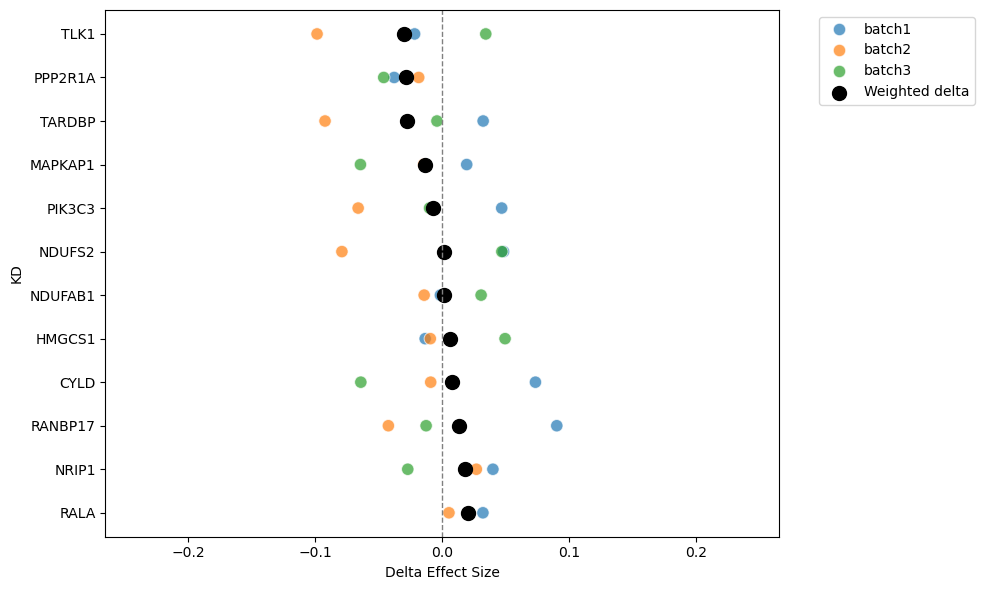

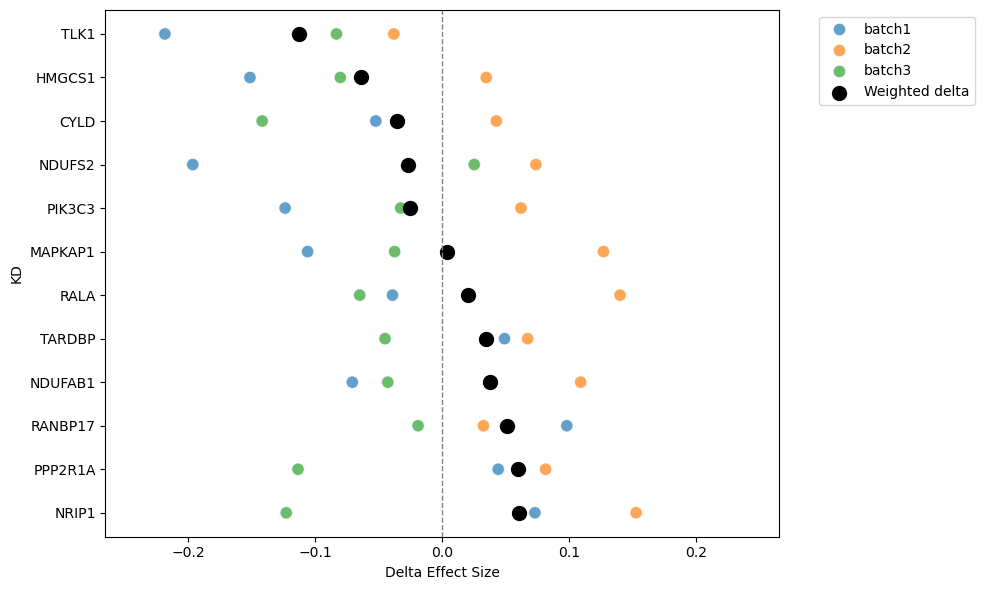

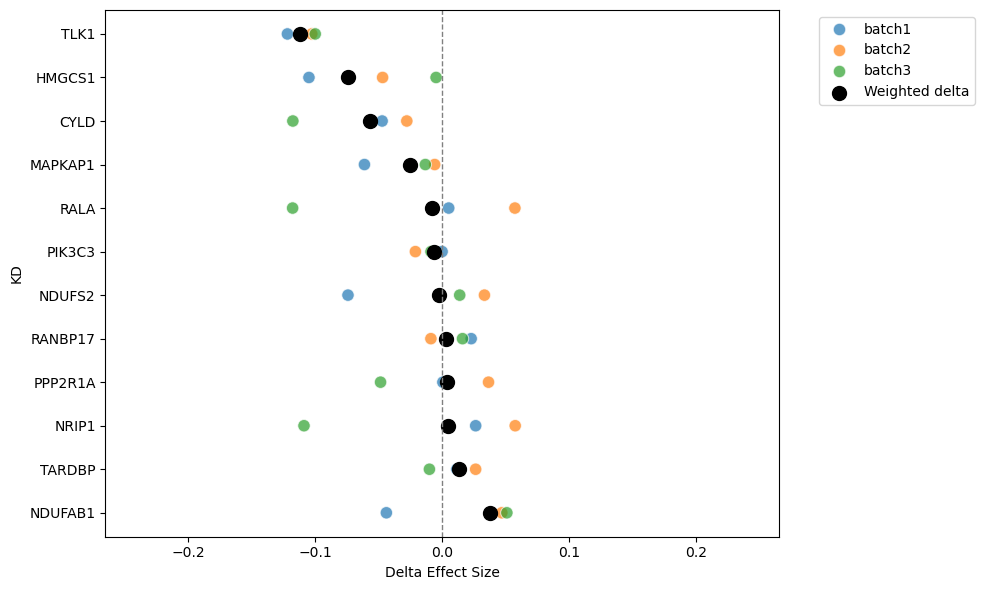

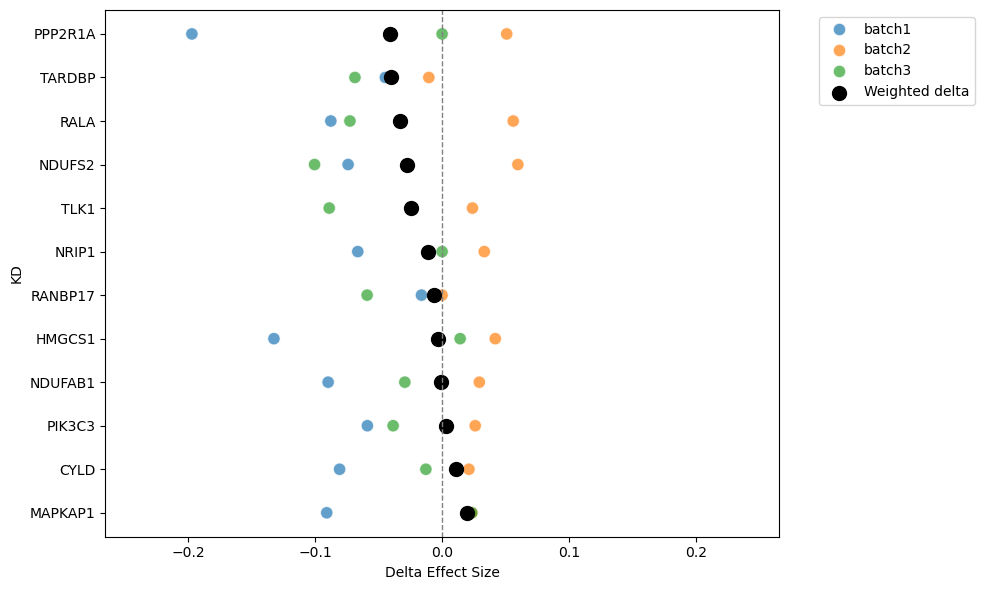

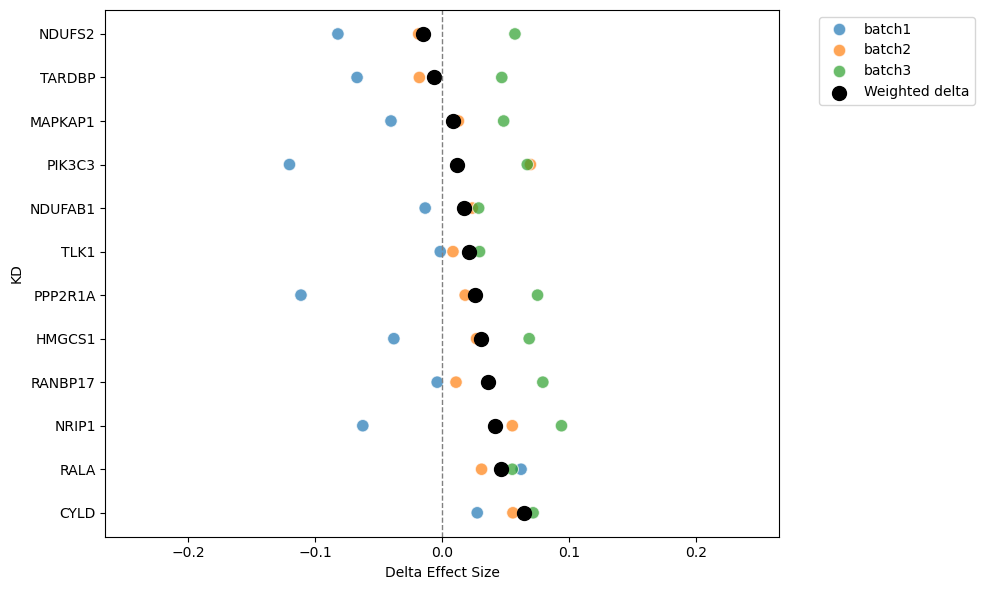

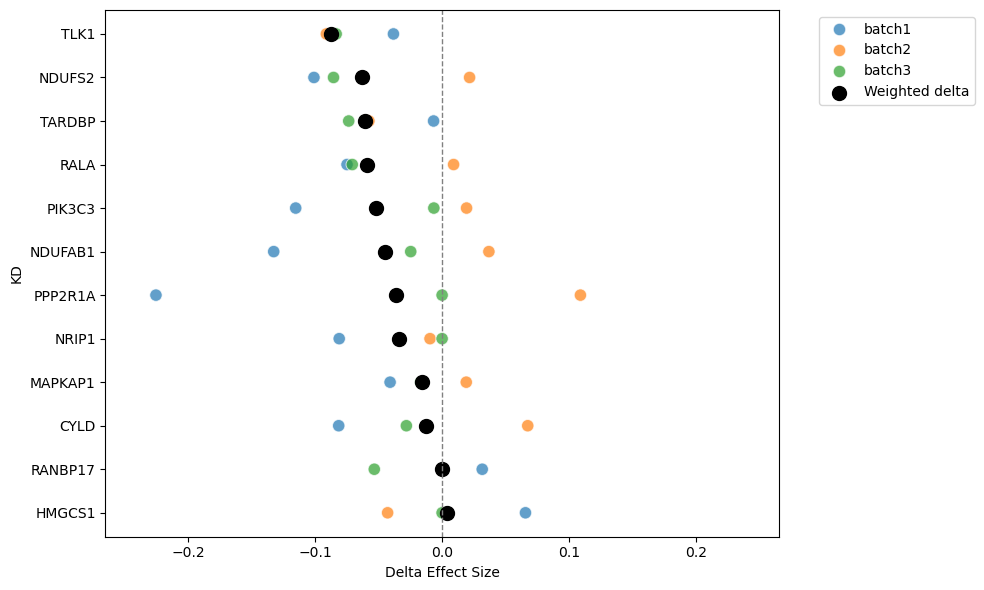

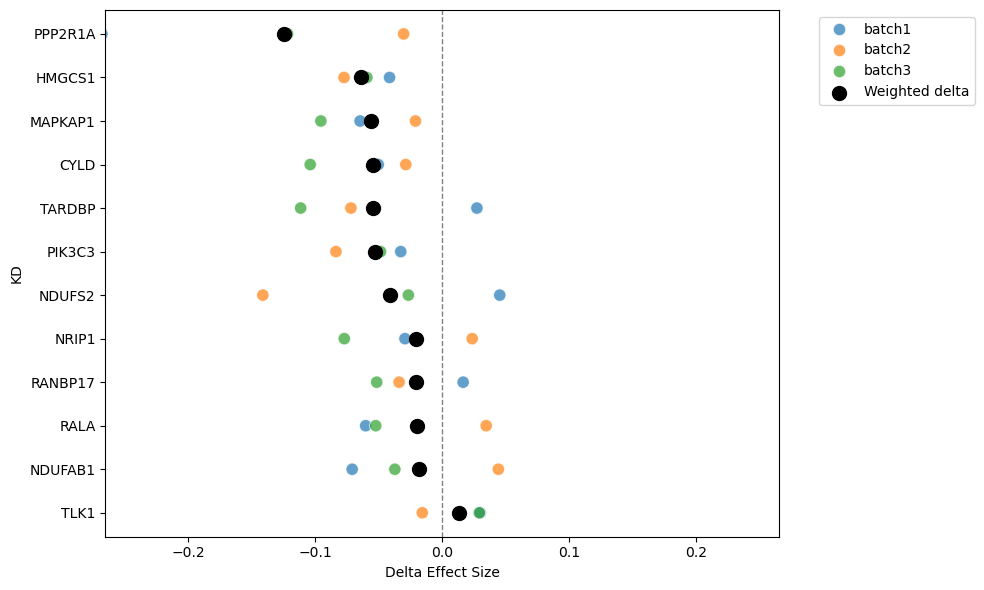

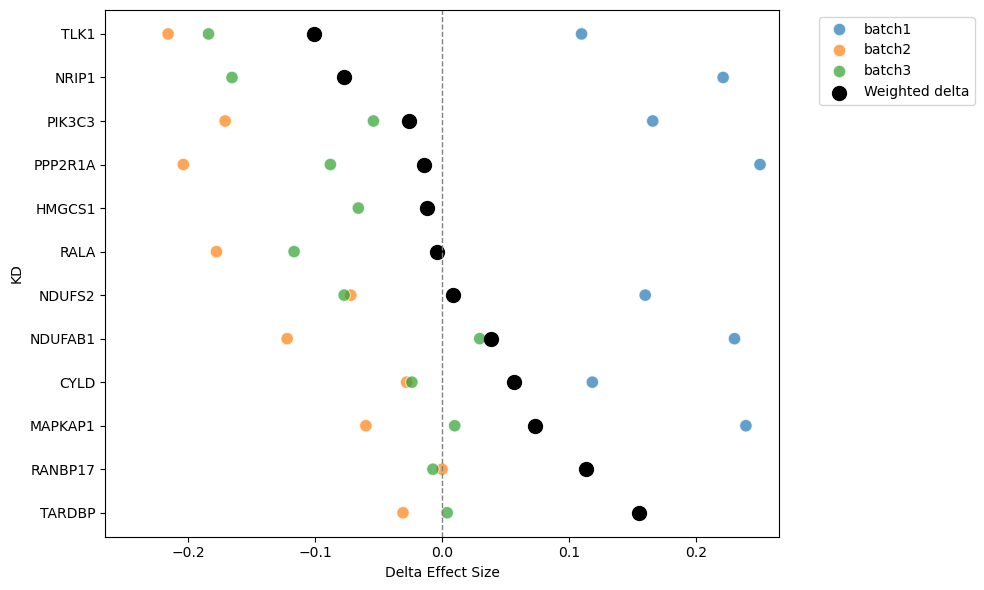

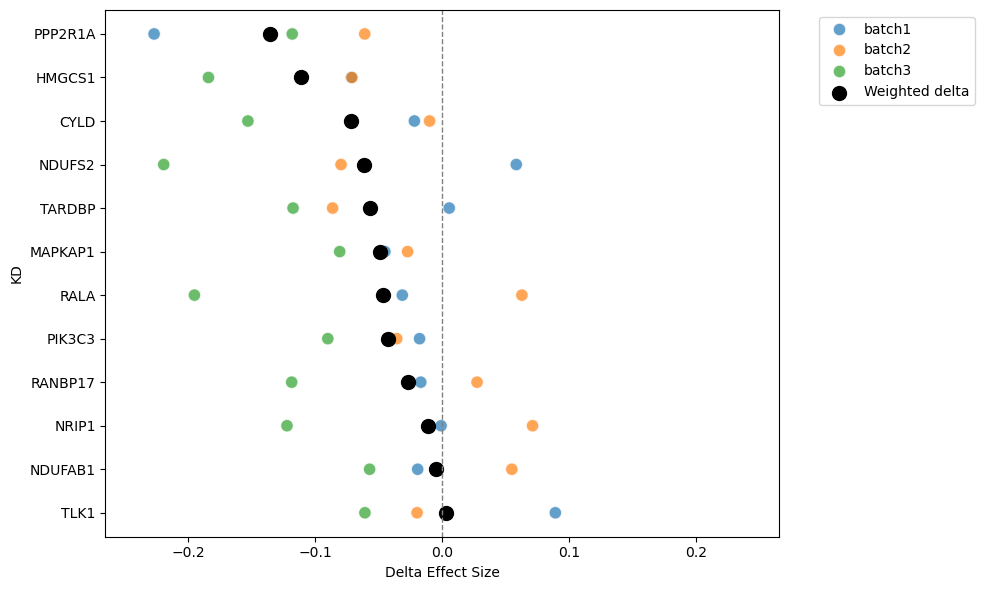

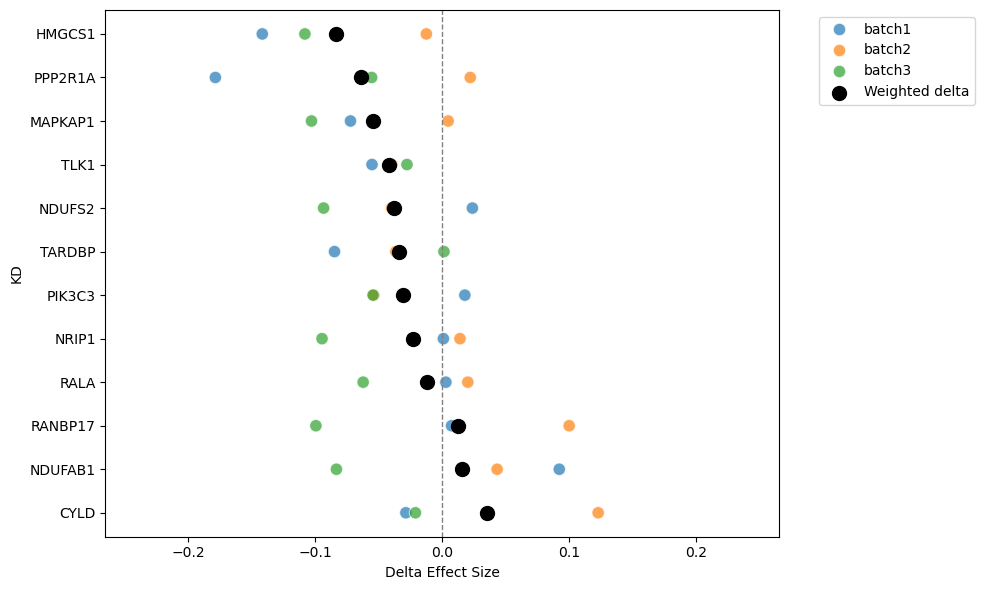

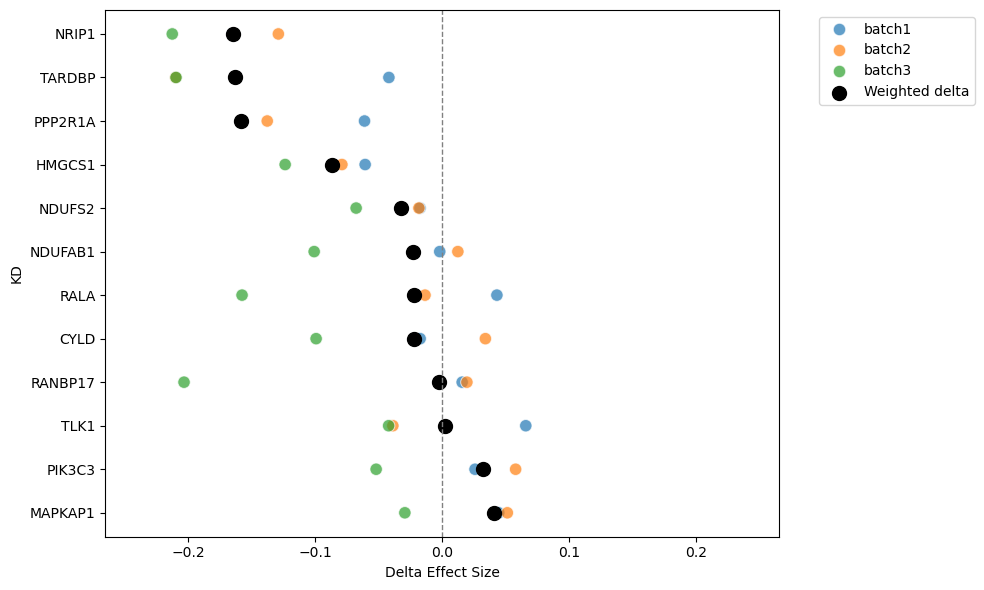

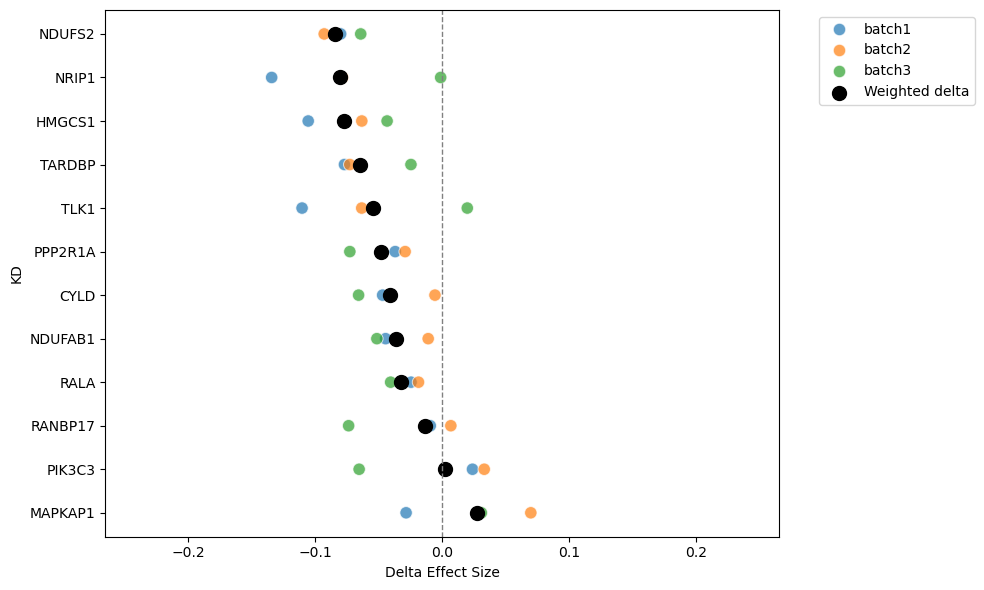

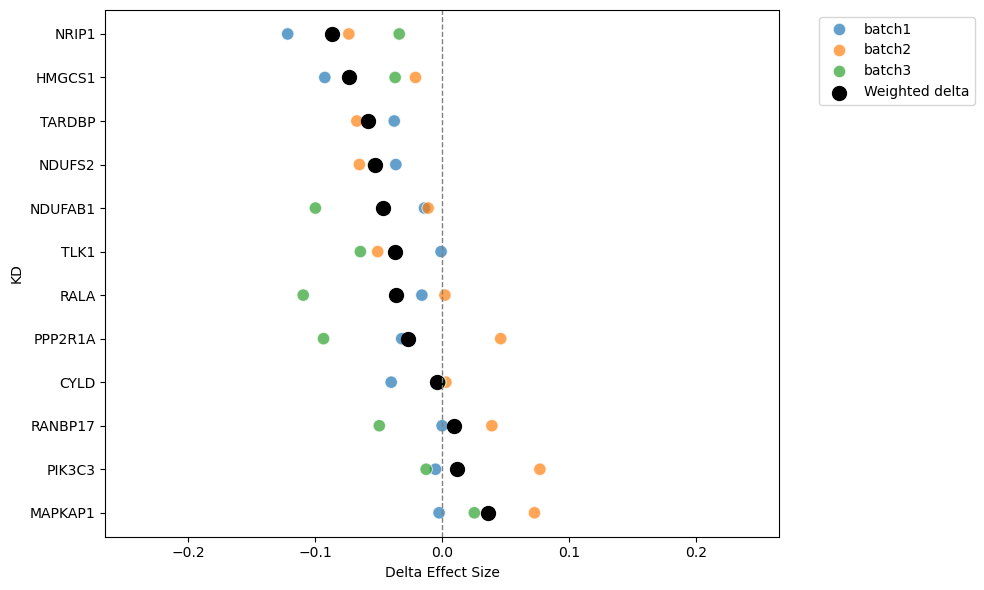

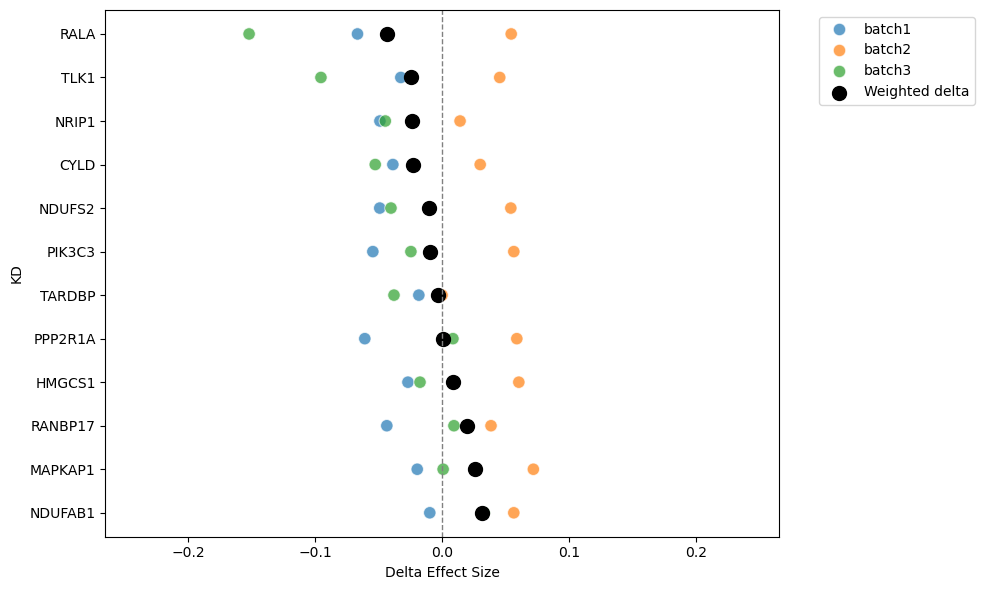

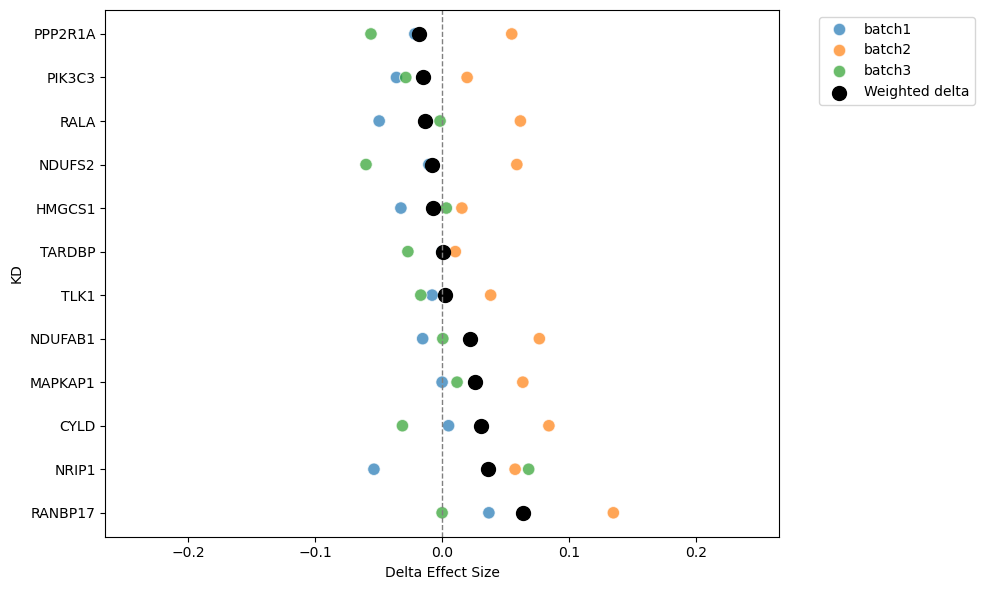

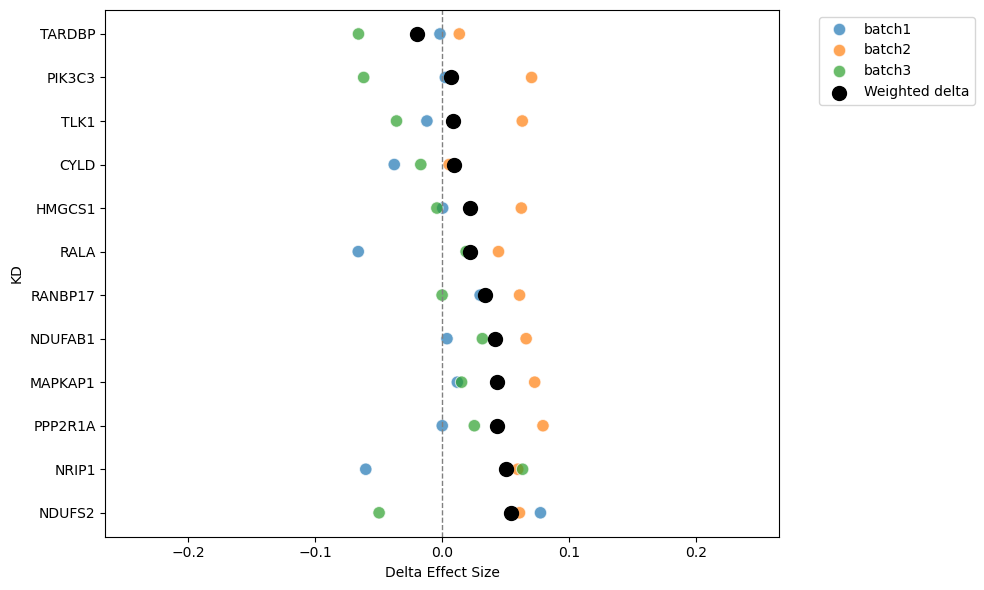

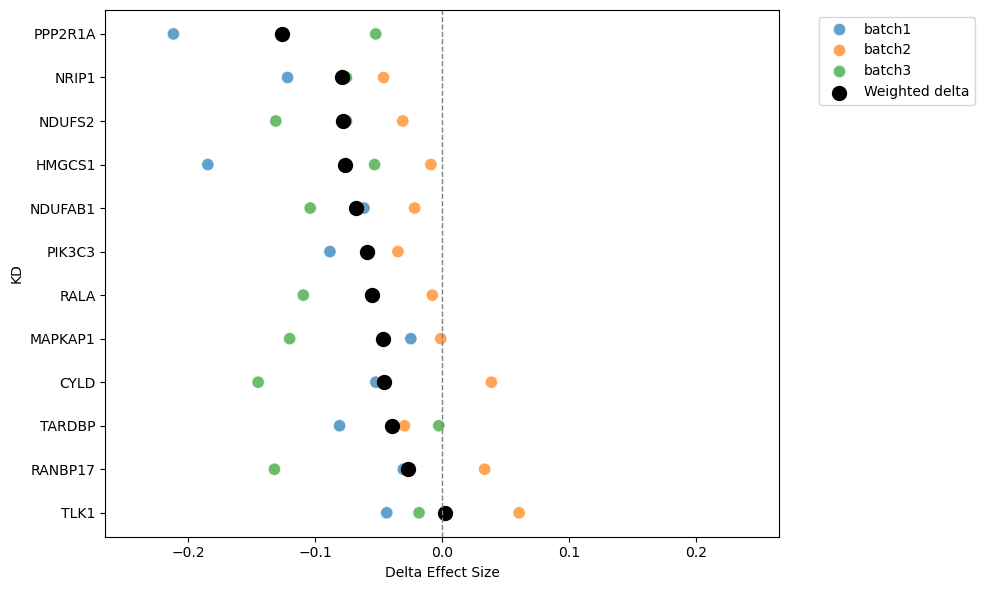

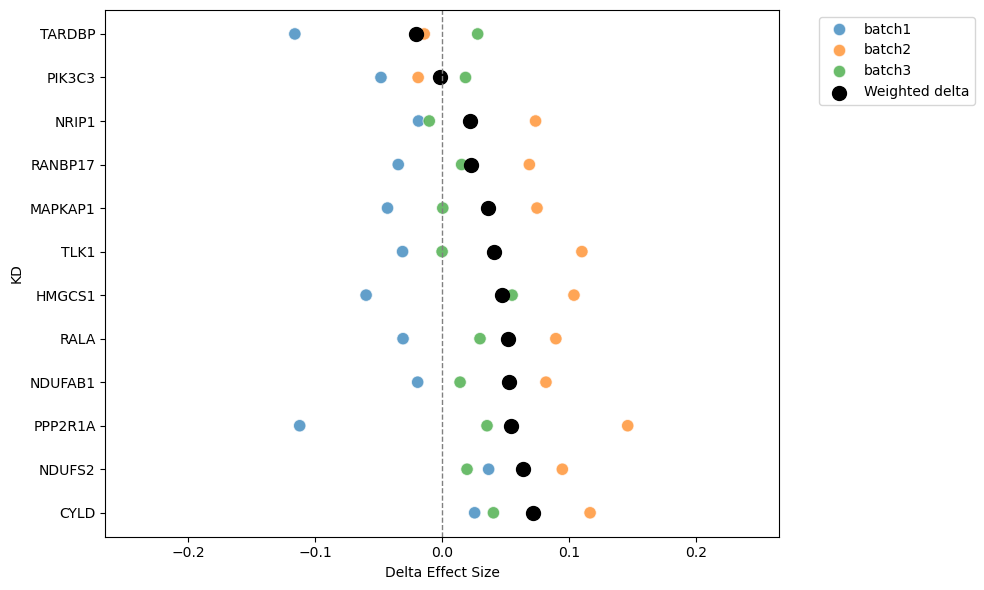

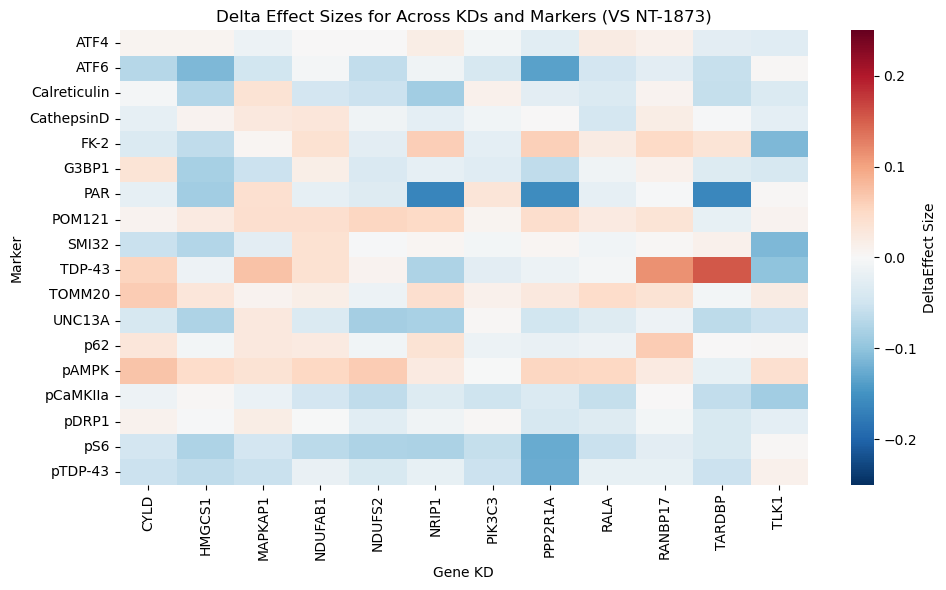

In [10]:
# all KDs heatmaps
import ast


BASELINE_PERT = [("CTL_NT-1873", "CTL_KD"), ("C9_NT-1873", "C9_KD")]

TEMP_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "All_KDs_VS_NT-1873")
os.makedirs(TEMP_OUTPUT_DIR, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)
all_delta_df = []
all_df = []
for marker in MARKERS:
    marker_df = []
    marker_df_delta = []
    print("*" * 20)
    print(f"Processing marker: {marker}")
    #itirate on subdirs
    for kd_name in os.listdir(OUTPUT_DIR):
        if kd_name not in KD_LIST:  
            continue
        print(f"Processing KD: {kd_name}")
        kd_df = []
        for baseline, pert in BASELINE_PERT:
            # read data
            df = pd.read_csv(os.path.join(OUTPUT_DIR, kd_name, f"{kd_name}_effect_sizes.csv"))
            weighted_df = pd.read_csv(os.path.join(OUTPUT_DIR, kd_name, f"{kd_name}_weighted_effect_sizes.csv"))

            # filter for marker
            df = df[df["marker"] == marker]
            weighted_df = weighted_df[weighted_df["marker"] == marker]

            # filter for comparison
            pert = pert.replace("KD", kd_name)
            print(f"Generating heatmap for -{baseline} VS {pert}")
            df = df[(df["baseline"] == baseline) & (df["pert"] == pert)]
            weighted_df = weighted_df[(weighted_df["baseline"] == baseline) & (weighted_df["pert"] == pert)]

            # add meta data
            weighted_df["KD"] = kd_name
            assert baseline.split('_')[0] == pert.split('_')[0], "Baseline and perturbed must be from the same cell_line"
            cell_line = baseline.split('_')[0]
            weighted_df["cell_line"] = cell_line

            # clip to positive only
            weighted_df["weighted_effect_size"] = weighted_df["weighted_effect_size"].clip(lower=0)
            df["effect_size"] = df["effect_size"].apply(
                    lambda x: ast.literal_eval(x)[0] if isinstance(x, str) else np.nan
            )
            df["effect_size"] = df["effect_size"].clip(lower=0)

            # add weighted df to store all data
            all_df.append(weighted_df)

            # merge weighted effect size and effect sizes per batch
            df = df.merge(
                    weighted_df[["marker", "baseline", "pert", "weighted_effect_size", "cell_line"]],
                    on=["marker", "baseline", "pert"],
                    how="left"
                )

            if len(df) == 0:
                print(f"No data, skipping...")
                continue
            kd_df.append(df)
            

        # add KD values
        if len(kd_df) > 0:
            kd_df = pd.concat(kd_df)
        else:
            print(f"No data, skipping kd...")
            continue
        
        marker_df.append(kd_df)
        # Calculate delta effect size
        delta_rows = []

        for batch in kd_df["batch"].unique():
            CTL_values = kd_df[(kd_df["cell_line"] == "CTL") & (kd_df["batch"] == batch)]["effect_size"].values
            C9_values = kd_df[(kd_df["cell_line"] == "C9") & (kd_df["batch"] == batch)]["effect_size"].values

            if len(CTL_values) == 0 or len(C9_values) == 0:
                print(f"Insufficient data for batch {batch}, skipping...")
                continue

            delta_rows.append({
                "marker": marker,
                "KD": kd_name,
                "batch": batch,
                "delta_effect_size": C9_values[0] - CTL_values[0]
            })

        CTL_values_weighted = kd_df[kd_df["cell_line"] == "CTL"]["weighted_effect_size"].values
        C9_values_weighted = kd_df[kd_df["cell_line"] == "C9"]["weighted_effect_size"].values
        if len(CTL_values_weighted) > 0 and len(C9_values_weighted) > 0:
            delta_rows.append({
                "marker": marker,
                "KD": kd_name,
                "batch": "weighted",
                "delta_effect_size": C9_values_weighted[0] - CTL_values_weighted[0],
            })

        delta_df = pd.DataFrame(delta_rows)
        marker_df_delta.append(delta_df)
        all_delta_df.append(delta_df)
    
    if len(marker_df_delta) > 0:
        marker_df_delta = pd.concat(marker_df_delta)
    else:
            print(f"No data, skipping marker...")
            continue
    # scatter plot of delta
    # Ensure KD order is correct (optional: sort by weighted delta)
    y_order = (
        marker_df_delta[marker_df_delta["batch"] == "weighted"]
        .sort_values("delta_effect_size", ascending=False)["KD"]
        .tolist()
    )

    # Make KD categorical so all layers align
    marker_df_delta["KD"] = pd.Categorical(marker_df_delta["KD"], categories=y_order, ordered=True)

    plt.figure(figsize=(10, 6))

    # 1️⃣ Batch-level deltas (colored by batch)
    sns.scatterplot(
        data=marker_df_delta[marker_df_delta["batch"] != "weighted"],
        x="delta_effect_size",
        y="KD",
        hue="batch",
        palette="tab10",
        s=80,
        alpha=0.7,
        zorder=1
    )

    # 2️⃣ Weighted delta (black)
    weighted_df = marker_df_delta[marker_df_delta["batch"] == "weighted"]
    weighted_df = weighted_df.sort_values("delta_effect_size", ascending=False)
    plt.scatter(
        weighted_df["delta_effect_size"],
        weighted_df["KD"],
        color="black",
        s=100,
        marker="o",
        label="Weighted delta",
        zorder=2,
    )

    # Optional: vertical line at 0
    plt.axvline(0, color="gray", linestyle="--", linewidth=1)

    plt.gca().invert_yaxis()  # match top-to-bottom order like heatmap

    plt.xlabel("Delta Effect Size")
    plt.ylabel("KD")
    plt.xlim((-(SCALE_MAX + 0.015), (SCALE_MAX+ 0.015)))
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    os.makedirs(os.path.join(TEMP_OUTPUT_DIR, marker), exist_ok = True)
    plt.savefig(os.path.join(TEMP_OUTPUT_DIR, marker, f"Marker_{marker}_delta_effect_size_scatter.png"))


all_delta_df = pd.concat(all_delta_df)
all_delta_df = all_delta_df[all_delta_df["batch"]=="weighted"]

all_delta_df_pivot = all_delta_df.pivot(index="marker", columns=["KD"], values="delta_effect_size")

# plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    all_delta_df_pivot,   
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "DeltaEffect Size"},
    vmin=-SCALE_MAX,
    vmax=SCALE_MAX,
)   
plt.title(f"Delta Effect Sizes for Across KDs and Markers (VS NT-1873)")
plt.ylabel("Marker")
plt.xlabel("Gene KD")
plt.tight_layout()
plt.savefig(os.path.join(TEMP_OUTPUT_DIR, f"All_KDs_All_Markers_Delta_effect_size_heatmap.png"))




In [11]:
all_df = pd.concat(all_df)
print(all_df.head())

  marker     baseline         pert  weighted_effect_size  \
3   ATF4  CTL_NT-1873  CTL_MAPKAP1              0.056542   
0   ATF4   C9_NT-1873   C9_MAPKAP1              0.042701   
3   ATF4  CTL_NT-1873    CTL_NRIP1              0.070999   
0   ATF4   C9_NT-1873     C9_NRIP1              0.088774   
2   ATF4  CTL_NT-1873  CTL_PPP2R1A              0.068428   

                                 baseline_counts  \
3  {'batch1': 290, 'batch2': 395, 'batch3': 230}   
0  {'batch1': 586, 'batch2': 479, 'batch3': 362}   
3  {'batch1': 290, 'batch2': 395, 'batch3': 230}   
0  {'batch1': 586, 'batch2': 479, 'batch3': 362}   
2  {'batch1': 290, 'batch2': 395, 'batch3': 230}   

                                     pert_counts       KD cell_line  
3  {'batch1': 246, 'batch2': 259, 'batch3': 180}  MAPKAP1       CTL  
0  {'batch1': 535, 'batch2': 449, 'batch3': 375}  MAPKAP1        C9  
3  {'batch1': 204, 'batch2': 270, 'batch3': 143}    NRIP1       CTL  
0  {'batch1': 378, 'batch2': 301, 'batch3': 27

In [12]:
import colorsys

marker_set = ["TDP-43"]
kds = KD_LIST
markers = marker_set
MARKER_TO_GREY_COLOR = []#["pTDP-43","ATF4", "FK-2", "SMI32", "pDRP1", "TOMM20", "pCaMKIIa", "ATF6", "G3BP1", "PAR", "UNC13A", "Calreticulin", "CathepsinD", "p62", "POM121", "pS6", "pAMPK"]
MARKERS_TO_COLOR = [
    marker for marker in marker_set
    if marker not in set(MARKER_TO_GREY_COLOR)
]
SUFFIX = ""
CONDITIONS_TO_SHOW = []#["RANBP17", "PPP2R1A"]

########## define x ticks positions #############
x_pos = {}
xticks = []
xtick_labels = []
x = 0
for kd in kds:
    x_pos[(kd, "CTL")] = x
    x_ctl = x
    x += 1

    x_pos[(kd, "C9")] = x
    x_c9 = x
    x += 1

    xticks.append((x_ctl + x_c9) / 2)
    xtick_labels.append(kd)

    x += 0.5  # spacing between KDs

######### assign colors per marker #############
base_colors = sns.color_palette("Spectral", len(markers))
marker_colors = {}
for marker, (r, g, b) in zip(markers, base_colors):
    h, l, s = colorsys.rgb_to_hls(r, g, b)

    # reduce lightness only if too bright
    if l > 0.7:
        l *= 0.5

    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
    marker_colors[marker] = (r2, g2, b2)
        

########### assign color per functional group ############
# one base color per functional group
group_names = list(FUNCTIONAL_MARKER_GROUPS.keys())
group_base_colors = dict(
    zip(group_names, sns.color_palette("tab10", len(group_names)))
)
marker_colors_functional = {}
# shades per marker within functional group
for group, markers_in_group in FUNCTIONAL_MARKER_GROUPS.items():
    base_r, base_g, base_b = group_base_colors[group]

    # convert base color to HLS
    h, l, s = colorsys.rgb_to_hls(base_r, base_g, base_b)

    # reduce lightness only if too bright
    if l > 0.7:
        l *= 0.6
        r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)
        group_base_colors[group] = (r2, g2, b2)

    n = len(markers_in_group)

    # create lightness range for shades
    # darker → lighter within same group
    lightness_values = (
        [l] if n == 1 else
        # np.linspace(max(0.35, l - 0.2), min(0.75, l + 0.15), n)
        np.linspace(
            max(0.25, l - 0.35),
            min(0.75, l + 0.3),
            n
        )
    )

    for marker, l_i in zip(markers_in_group, lightness_values):
        r2, g2, b2 = colorsys.hls_to_rgb(h, l_i, s)
        marker_colors_functional[marker] = (r2, g2, b2)

# initi gray color
# Get a palette
palette = sns.color_palette("grey", n_colors=5)
# Pick one color
r_grey, g_grey, b_grey = palette[2]

if (len(MARKER_TO_GREY_COLOR) > 0) and (len(CONDITIONS_TO_SHOW)) == 0:
    SUFFIX = "_color_on" + "_".join(MARKERS_TO_COLOR)
    
    for marker in MARKER_TO_GREY_COLOR:
        marker_colors[marker] = (r_grey, g_grey, b_grey)
        marker_colors_functional[marker] = (r_grey, g_grey, b_grey)

if len(CONDITIONS_TO_SHOW) > 0:
    SUFFIX = "_color_on" + "_".join(CONDITIONS_TO_SHOW)

########### cell lines styles ############
style_handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='none',
        markeredgecolor='black',
        label='CTL'
    ),
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        markerfacecolor='black',
        markeredgecolor='black',
        label='C9'
    )
    ]

def adjust_alpha(color, alpha):
    return (*color, alpha)

def plot_basic_interaction_plot(marker_colors_dict):
    fig, ax = plt.subplots(figsize=(16, 6))
    markers = marker_colors_dict.keys()
    for marker in markers:
        df_m = all_df[all_df["marker"] == marker]
        base_color = marker_colors_dict[marker]

        for kd in kds:
            if len(CONDITIONS_TO_SHOW) > 0 and kd not in set(CONDITIONS_TO_SHOW):
                kd_color = (r_grey, g_grey, b_grey)
            else:
                kd_color = base_color
            
            sub = df_m[df_m["KD"] == kd]
            if set(sub["cell_line"]) != {"CTL", "C9"}:
                continue

            ctl = sub[sub["cell_line"] == "CTL"]["weighted_effect_size"].values[0]
            c9  = sub[sub["cell_line"] == "C9"]["weighted_effect_size"].values[0]

            x_ctl = x_pos[(kd, "CTL")]
            x_c9  = x_pos[(kd, "C9")]

            # connecting line
            ax.plot(
                [x_ctl, x_c9],
                [ctl, c9],
                color=kd_color,
                alpha=0.5,
                linewidth=1
            )

            # CTL – hollow
            ax.scatter(
                x_ctl, ctl,
                facecolors="none",
                edgecolors=kd_color,
                s=50,
                linewidth=1.5,
                zorder=3
            )

            # C9 – filled
            ax.scatter(
                x_c9, c9,
                facecolors=kd_color,
                edgecolors=kd_color,
                s=50,
                zorder=3
            )
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, rotation=45, ha="right")

    ax.set_ylabel("Weighted Effect Size")
    ax.set_xlabel("KD / Cell line")
    ax.set_title("CTL vs C9 Interaction Plot Across KDs and Markers")


    return fig, ax


if PLOT_INTERCATION_PLOT:
    # ######### plot basic interaction plot #############
    fig, ax = plot_basic_interaction_plot(marker_colors)
    # legend (marker-based)
    marker_handles = [
        plt.Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markerfacecolor=color,
            markeredgecolor=color,
            label=marker
        )
        for marker, color in marker_colors.items()
    ]

    leg1 = ax.legend(
        handles=marker_handles,
        title="Marker",
        bbox_to_anchor=(1.005, 1),
        loc="upper left"
    )
    ax.add_artist(leg1)

    ax.legend(
        handles=style_handles,
        title="Cell line",
        bbox_to_anchor=(1.005, 0.0),
        loc="upper left"
        )
    plt.savefig(os.path.join(TEMP_OUTPUT_DIR, f"All_KDs_All_Markers_interaction_plot{SUFFIX}.png"), bbox_inches='tight', dpi=300,pad_inches=0.8)

# ######### plot interaction plot with functional groups #############

if PLOT_INTERCATION_PLOT_BY_FUNCTIONAL_GROUPS:
    # ######### plot basic interaction plot #############
    fig, ax = plot_basic_interaction_plot(marker_colors_functional)
    marker_handles_functional = []
    for group, markers_in_group in FUNCTIONAL_MARKER_GROUPS.items():
        for marker in markers_in_group:
            color = marker_colors_functional[marker]
            marker_handles_functional.append(
                plt.Line2D(
                    [0], [0],
                    marker='o',
                    linestyle='',
                    markerfacecolor=color,
                    markeredgecolor=color,
                    label=f"{marker}"
                )
            )
    groups_handels = [
        plt.Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markerfacecolor=group_base_colors[group],
            markeredgecolor=group_base_colors[group],
            label=f"{group}"
        )
        for group in FUNCTIONAL_MARKER_GROUPS.keys()
    ]
    leg1 = ax.legend(
        handles=marker_handles_functional,
        title="Markers",
        bbox_to_anchor=(1.005, 1.10),
        loc="upper left"
    )
    ax.add_artist(leg1)

    leg_2 = ax.legend(
        handles=groups_handels,
        title="Functional groups",
        bbox_to_anchor=(1.005, 0.2),
        loc="upper left"
    )
    ax.add_artist(leg_2)
    ax.legend(
        handles=style_handles,
        title="Cell line",
        bbox_to_anchor=(1.005, -0.15),
        loc="upper left"
        )
    plt.savefig(os.path.join(TEMP_OUTPUT_DIR, f"All_KDs_All_Markers_functional_groups_interaction_plot{SUFFIX}.png"), bbox_inches='tight', dpi=300,pad_inches=1.1)

In [13]:
# --- Interaction-style plots per cell type, with batch shapes ---
BATCHES_TO_SHOW = ["batch1", "batch2", "batch3"]  # select which batches to display

if PLOT_INTERACTION_PER_CELL_TYPE:
    BATCH_SHAPES = {"batch1": "o", "batch2": "s", "batch3": "^"}
    BATCH_DODGE_WIDTH = 0.25  # total spread around the KD center position

    # Load all per-batch effect sizes from CSVs
    all_batch_rows = []
    for kd_name in KD_LIST:
        csv_path = os.path.join(OUTPUT_DIR, kd_name, f"{kd_name}_effect_sizes.csv")
        if not os.path.exists(csv_path):
            continue
        df = pd.read_csv(csv_path)
        df["effect_size_val"] = df["effect_size"].apply(
            lambda x: ast.literal_eval(x)[0] if isinstance(x, str) else np.nan
        )
        df["effect_size_val"] = df["effect_size_val"].clip(lower=0)
        df["KD"] = kd_name
        df["cell_line"] = df["baseline"].str.split("_").str[0]
        all_batch_rows.append(df)

    all_batch_df = pd.concat(all_batch_rows, ignore_index=True)

    # Keep only NT-1873 vs KD comparisons within the same cell line
    all_batch_df = all_batch_df[all_batch_df["baseline"].str.endswith("_NT-1873")]
    all_batch_df["pert_cell_line"] = all_batch_df["pert"].str.split("_").str[0]
    all_batch_df = all_batch_df[all_batch_df["cell_line"] == all_batch_df["pert_cell_line"]]

    # Filter to selected batches
    all_batch_df = all_batch_df[all_batch_df["batch"].isin(BATCHES_TO_SHOW)]

    # Compute x offsets per batch: evenly spaced around 0
    n_batches = len(BATCHES_TO_SHOW)
    batch_offsets = {
        batch: -BATCH_DODGE_WIDTH / 2 + i * BATCH_DODGE_WIDTH / max(n_batches - 1, 1)
        for i, batch in enumerate(BATCHES_TO_SHOW)
    }

    # x positions: one per KD
    kd_x_positions = {kd: i for i, kd in enumerate(KD_LIST)}

    for cell_type in ["CTL", "C9"]:
        cell_batch = all_batch_df[all_batch_df["cell_line"] == cell_type]
        cell_weighted = all_df[all_df["cell_line"] == cell_type]

        fig, ax = plt.subplots(figsize=(16, 6))

        for marker in MARKERS:
            color = marker_colors[marker]
            m_batch = cell_batch[cell_batch["marker"] == marker]
            m_weighted = cell_weighted[cell_weighted["marker"] == marker]

            # Connect weighted values across KDs with a line
            xs, ys = [], []
            for kd in KD_LIST:
                w = m_weighted[m_weighted["KD"] == kd]
                if len(w) > 0:
                    xs.append(kd_x_positions[kd])
                    ys.append(w["weighted_effect_size"].values[0])
            if len(xs) > 1:
                ax.plot(xs, ys, color=color, alpha=0.4, linewidth=1, zorder=1)

            for kd in KD_LIST:
                x_center = kd_x_positions[kd]

                # Per-batch points with different shapes, dodged on x
                kd_m = m_batch[m_batch["KD"] == kd]
                for _, row in kd_m.iterrows():
                    batch = row["batch"]
                    shape = BATCH_SHAPES.get(batch, "D")
                    x_dodged = x_center + batch_offsets[batch]
                    ax.scatter(
                        x_dodged, row["effect_size_val"],
                        facecolors=color, edgecolors=color,
                        marker=shape, s=40, alpha=0.5, zorder=2,
                    )

                # Weighted average point (black edge to distinguish)
                w = m_weighted[m_weighted["KD"] == kd]
                if len(w) > 0:
                    ax.scatter(
                        x_center, w["weighted_effect_size"].values[0],
                        facecolors=color, edgecolors="black",
                        marker="D", s=70, linewidth=1, zorder=3,
                    )

        ax.set_xticks(list(kd_x_positions.values()))
        ax.set_xticklabels(KD_LIST, rotation=45, ha="right")
        ax.set_ylabel("Effect Size")
        ax.set_xlabel("Gene KD")
        ax.set_title(f"{cell_type}: Effect Size Across KDs and Markers (by Batch)")

        # Marker color legend
        marker_legend_handles = [
            plt.Line2D([0], [0], marker='o', linestyle='',
                       markerfacecolor=marker_colors[m], markeredgecolor=marker_colors[m], label=m)
            for m in MARKERS
        ]
        leg1 = ax.legend(handles=marker_legend_handles, title="Marker",
                         bbox_to_anchor=(1.005, 1), loc="upper left", fontsize=8)
        ax.add_artist(leg1)

        # Batch shape legend (only shown batches)
        batch_handles = [
            plt.Line2D([0], [0], marker=BATCH_SHAPES[batch], linestyle='', color='black',
                       markerfacecolor='gray', label=batch)
            for batch in BATCHES_TO_SHOW
        ]
        batch_handles.append(
            plt.Line2D([0], [0], marker='D', linestyle='',
                       markerfacecolor='gray', markeredgecolor='black',
                       label='Weighted avg')
        )
        ax.legend(handles=batch_handles, title="Batch",
                  bbox_to_anchor=(1.005, 0.0), loc="lower left")

        plt.tight_layout()
        plt.savefig(
            os.path.join(TEMP_OUTPUT_DIR,
                         f"All_KDs_All_Markers_{cell_type}_interaction_by_batch{SUFFIX}.png"),
            bbox_inches='tight', dpi=300,
        )

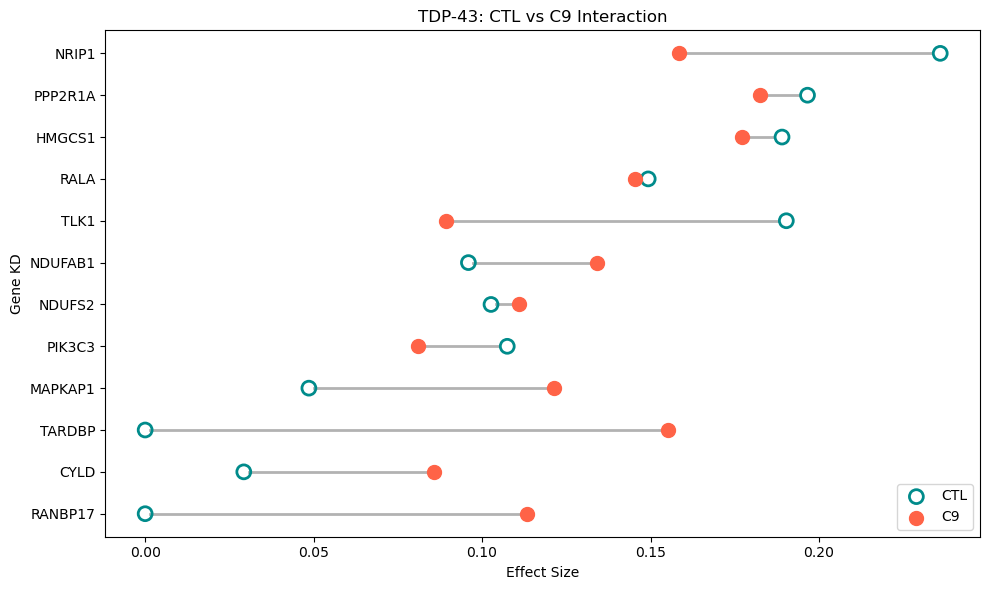

In [17]:
# --- Single-marker interaction plot (weighted only) ---
SINGLE_MARKER = "TDP-43"

df_marker = all_df[all_df["marker"] == SINGLE_MARKER].copy()

# Keep only KDs that have both cell lines
valid_kds = (
    df_marker.groupby("KD")["cell_line"]
    .apply(lambda x: set(x) == {"CTL", "C9"})
)
valid_kds = valid_kds[valid_kds].index.tolist()
df_marker = df_marker[df_marker["KD"].isin(valid_kds)]

# Pivot to get CTL and C9 side by side
pivot = df_marker.pivot(index="KD", columns="cell_line", values="weighted_effect_size")
pivot = pivot.reindex(KD_LIST)  # keep original KD order
pivot = pivot.dropna()

# Sort by mean effect size (descending) for a cleaner look
pivot["mean"] = (pivot["CTL"] + pivot["C9"]) / 2
pivot = pivot.sort_values("mean", ascending=False)
pivot = pivot.drop(columns="mean")



fig, ax = plt.subplots(figsize=(10, 6))

y_positions = range(len(pivot))

for i, (kd, row) in enumerate(pivot.iterrows()):
    ctl_val = row["CTL"]
    c9_val = row["C9"]

    # Connecting line
    ctl_val_line = ctl_val+0.0015 if ctl_val < c9_val else ctl_val-0.0025
    ax.plot(
        [ctl_val_line, c9_val], [i, i],
        color="grey", linewidth=2, alpha=0.6, zorder=1
    )
    # CTL - hollow
    ax.scatter(
        ctl_val, i,
        facecolors="none", edgecolors="darkcyan",
        s=100, linewidth=2, zorder=3, label="CTL" if i == 0 else ""
    )
    # C9 - filled
    ax.scatter(
        c9_val, i,
        facecolors="tomato", edgecolors="tomato",
        s=100, zorder=3, label="C9" if i == 0 else ""
    )

ax.set_yticks(list(y_positions))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Effect Size")
ax.set_ylabel("Gene KD")
ax.set_title(f"{SINGLE_MARKER}: CTL vs C9 Interaction")
ax.legend(loc="lower right")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(
    os.path.join(TEMP_OUTPUT_DIR, f"{SINGLE_MARKER}_interaction_weighted.png"),
    bbox_inches='tight', dpi=300,
)

In [15]:
import ast
# all KDs heatmaps
base_line_pert_kd_main_effect = [("C9_CTL:NT-1873", "C9_CTL:KD")]
base_line_pert_kd_ctl = [("CTL_NT-1873", "CTL_KD")]
base_line_pert_kd_c9 = [("C9_NT-1873", "C9_KD")]

TEMP_OUTPUT_DIR = os.path.join(OUTPUT_DIR, "All_KDs_VS_NT-1873")
os.makedirs(TEMP_OUTPUT_DIR, exist_ok=True)

print("OUTPUT_DIR:", OUTPUT_DIR)

def plot_all_kds(file_suffix:str, base_line_pert:list, group_seperator:str, comparison_str:str):
        all_main_effect_df = []
        for marker in MARKERS:
            marker_df = []
            print("*" * 20)
            print(f"Processing marker: {marker}")
            #itirate on subdirs
            for kd_name in os.listdir(OUTPUT_DIR):
                if kd_name not in KD_LIST:  
                    continue
                print(f"Processing KD: {kd_name}")

                kd_df = []
                for baseline, pert in base_line_pert:
                    df = pd.read_csv(os.path.join(OUTPUT_DIR, kd_name, f"{kd_name}_effect_sizes{file_suffix}.csv"))
                    weighted_df = pd.read_csv(os.path.join(OUTPUT_DIR, kd_name, f"{kd_name}_weighted_effect_sizes{file_suffix}.csv"))

                    # extract common group
                    g1_a = baseline.split(group_seperator)[0]
                    g1_b = baseline.split(group_seperator)[1]
                    g2_a = pert.split(group_seperator)[0]
                    g2_b = pert.split(group_seperator)[1]
                    assert (g1_a == g2_a) ^ (g1_b==g2_b), "Baseline and perturbed must share a group, and to have comparison"
                    shared = g1_a if (g1_a == g2_a) else g1_b
                    compared = f"{g1_a} vs {g2_a}" if (g1_a != g2_a) else f"{g1_b} vs {g2_b}"
                    # get KD effect name
                    pert = pert.replace("KD", kd_name)
                    print(f"Generating heatmap for -{baseline} VS {pert}")

                    # filter to have marker only
                    df = df[df["marker"] == marker]
                    weighted_df = weighted_df[weighted_df["marker"] == marker]


                    # filter
                    df = df[(df["baseline"] == baseline) & (df["pert"] == pert)]
                    weighted_df = weighted_df[(weighted_df["baseline"] == baseline) & (weighted_df["pert"] == pert)]
                    df["KD"] = kd_name

                    # clip to positive only
                    weighted_df["weighted_effect_size"] = weighted_df["weighted_effect_size"].clip(lower=0)
                    df["effect_size"] = df["effect_size"].apply(
                        lambda x: ast.literal_eval(x)[0] if isinstance(x, str) else np.nan
                    )
                    df["effect_size"] = df["effect_size"].clip(lower=0)

                    # merge weighted effect size
                    df = df.merge(
                        weighted_df[["marker", "baseline", "pert", "weighted_effect_size"]],
                        on=["marker", "baseline", "pert"],
                        how="left"
                    )

                    df["group"] = shared

                    if len(df) == 0:
                        print(f"No data, skipping...")
                        continue

                    kd_df.append(df)

                # add KD values
                kd_df = pd.concat(kd_df)
                marker_df.append(kd_df)

            marker_df = pd.concat(marker_df)
            all_main_effect_df.append(marker_df)

            # scatter plot with all points per batch and weighted average
            plt.figure(figsize=(10, 6))
            y_order = (
                marker_df
                .drop_duplicates("KD")
                .sort_values("weighted_effect_size", ascending=False)["KD"]
                .tolist()
            )
            marker_df["KD"] = pd.Categorical(
                marker_df["KD"],
                categories=y_order,
                ordered=True,
            )

            sns.scatterplot(
                data=marker_df,
                x="effect_size",
                y="KD",
                hue="batch",
                palette="tab10",
                s=80,
                alpha=0.45,
                zorder=1,
            )

            weighted_df = marker_df.drop_duplicates("KD")
            weighted_df = weighted_df.sort_values("weighted_effect_size", ascending=False)

            plt.scatter(
                weighted_df["weighted_effect_size"],
                weighted_df["KD"],
                color="black",
                s=100,
                marker="o",
                label="Weighted effect",
                zorder=2,
            )
            plt.title(f"Effect Sizes for {marker}: {compared} \n{comparison_str} in {shared}")
            plt.axvline(0, color="gray", linestyle="--", linewidth=1)
            plt.yticks(ticks=range(len(y_order)), labels=y_order)
            plt.gca().invert_yaxis()                 # match heatmap top-to-bottom order

            plt.xlabel("Effect Size")
            plt.ylabel("KD")
            plt.xlim(((SCALE_MIN - 0.015), (SCALE_MAX + 0.015)))
            plt.tight_layout()
            plt.savefig(os.path.join(TEMP_OUTPUT_DIR, marker, f"Marker_{marker}_{comparison_str.replace(' ', '_')}_in_{shared}_scatter.png"))

        all_main_effect_df = pd.concat(all_main_effect_df)
        all_main_effect_df = all_main_effect_df[["marker", "KD", "weighted_effect_size"]]
        all_main_effect_df = all_main_effect_df.drop_duplicates(subset=["marker", "KD", "weighted_effect_size"], keep='first')
        all_main_effect_df_pivot = all_main_effect_df.pivot(index="KD", columns=["marker"], values="weighted_effect_size")

        # Group by markers functional groups
        # current marker order
        markers = all_main_effect_df_pivot.columns.tolist()

        # sort markers by functional group, then alphabetically
        markers_sorted = sorted(
            markers,
            key=lambda m: (MARKER_TO_GROUP.get(m, "Other"), m)
        )
        all_main_effect_df_pivot = all_main_effect_df_pivot[markers_sorted]

        # plot heatmap
        plt.figure(figsize=(10, 6))
        ax = sns.heatmap(
            all_main_effect_df_pivot,
            cmap="RdBu_r",
            center=0,
            cbar_kws={"label": f"{comparison_str} in {shared}"},
            vmin=SCALE_MIN,
            vmax=SCALE_MAX,
        )   

        # Increase padding for the X-axis label even more to accommodate rotated text
        plt.xlabel("Marker", labelpad=100, fontsize=12, fontweight='bold')

        # Add group labels at the bottom with lines
        group_positions = {}
        for i, marker in enumerate(markers_sorted):
            group = MARKER_TO_GROUP.get(marker, "Other")
            group_positions.setdefault(group, []).append(i)

        n_rows = all_main_effect_df_pivot.shape[0]
        
        # Adjust these for vertical depth
        line_y = n_rows + 2.8  
        text_y = line_y + 0.8  # More gap for rotated text
        tick_size = 0.3

        for group, positions in group_positions.items():
            start = min(positions) + 0.05
            end = max(positions) + 0.95
            center = (start + end) / 2
            
            # Draw horizontal line
            ax.plot([start, end], [line_y, line_y], color='black', lw=1.5, 
                    transform=ax.transData, clip_on=False)
            
            # Draw vertical ticks
            ax.plot([start, start], [line_y, line_y - tick_size], color='black', lw=1.5, 
                    transform=ax.transData, clip_on=False)
            ax.plot([end, end], [line_y, line_y - tick_size], color='black', lw=1.5, 
                    transform=ax.transData, clip_on=False)
            
            # Add Rotated Group Text
            ax.text(
                center,
                text_y,
                group,
                ha="right",      # 'right' alignment works best with rotation
                va="top",
                fontsize=10,
                fontweight='bold',
                rotation=45,     # Rotate 45 degrees to prevent overlap
                transform=ax.transData,
                clip_on=False
            )
        plt.title(f"{compared} Effect Sizes Across KDs and Markers\n{comparison_str} in {shared}")
        plt.ylabel("Gene KD")
        plt.xlabel("Marker")
        plt.subplots_adjust(bottom=0.2)
        plt.savefig(os.path.join(TEMP_OUTPUT_DIR, f"All_KDs_All_Markers_{comparison_str.replace(' ', '_')}_in_{shared}_heatmap.png"))

if PLOT_ALL_KDS_MAIN_EFFECT:
    plot_all_kds("_aggregated", base_line_pert_kd_main_effect, ":", "KD main effect")

if PLOT_ALL_KDS_EFFECT:
    plot_all_kds("", base_line_pert_kd_ctl, "_", "KD effect")
    plot_all_kds("", base_line_pert_kd_c9, "_", "KD effect")



OUTPUT_DIR: /home/projects/hornsteinlab/Collaboration/Guy_Lior/fuNOVA_Pilot2/Effect_size/after_outlier_removal
